RandomResizedCrop

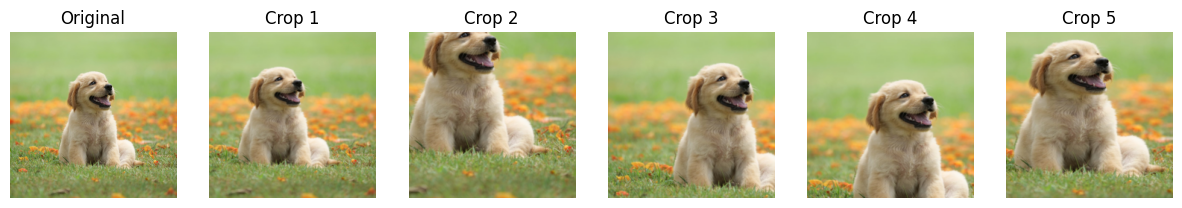

In [2]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Function to visualize RandomResizedCrop
def visualize_random_resized_crop():
    # Load a sample image (ImageNet-like)
    url = "https://hips.hearstapps.com/hmg-prod/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg?crop=0.752xw:1.00xh;0.175xw,0&resize=1200:*"
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("RGB")
    except:
        print("Failed to download image, using random noise.")
        img = Image.fromarray(torch.randint(0, 255, (224, 224, 3), dtype=torch.uint8).numpy())

    # random_resized_crop parameters
    transform = transforms.RandomResizedCrop(size=(224, 224))

    num_crops = 5
    crops = [transform(img) for _ in range(num_crops)]

    fig, axs = plt.subplots(1, num_crops + 1, figsize=(15, 5))
    axs[0].imshow(img)
    axs[0].set_title("Original")
    axs[0].axis("off")

    for i, crop in enumerate(crops):
        axs[i+1].imshow(crop)
        axs[i+1].set_title(f"Crop {i+1}")
        axs[i+1].axis("off")

    plt.show()

visualize_random_resized_crop()